# **Classification of Claims in TikTok Videos**
**Second Stage - Exploratory Data Analysis**

**Situation:** We're still in the early stages of the project. So far, we've completed a project proposal and used Python to inspect and organize the dataset.

Next, we're going to perform some Exploratory Data Analysis (EDA) and data visualization. This Python notebook shows data structuring and cleaning, as well as any matplotlib/seaborn visualizations plotted to help us understand the data. And at the very least, includes a graph comparing claim counts to opinion counts, as well as boxplots of the most important variables (like “video duration,” “video like count,” “video comment count,” and “video view count”) to check for outliers. Also, include a breakdown of “author ban status” counts.

For this data, we'll also create a Tableau dashboard showing a simple claims versus opinions count, as well as stacked bar charts of claims versus opinions for variables like video view counts, video like counts, video share counts, and video download counts. I'll sure it is easy to understand to someone who isn't data savvy, or is a person with visual impairments.

# **Stage 2: Exploratory data analysis**

In this stage, we'll will examine data provided and prepare it for analysis. We will also design a professional data visualization that tells a story, and will help data-driven decisions for business needs.


**The purpose** of this stage is to conduct exploratory data analysis on a provided data set. Our mission is to continue the investigation we began in the 1st stage and perform further EDA on this data with the aim of learning more about the variables. Of particular interest is information related to what distinguishes claim videos from opinion videos.

**The goal** is to explore the dataset and create visualizations.
<br/>
*This stage has 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration & Data cleaning


**Part 3:** Building visualizations

**Part 4:** Evaluating and sharing results

# **Visualizing a story in Tableau and Python**

# **PACE stages**

Throughout the project notebooks, we'll use the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

## **PACE: Plan**

1. Identifying outliers:

There are three methods for identifing ouliers: comparing the mean and median, using box plot, and using histogram.
Our decision might be to remove them, reassign them or to keep them, depinding on the dataset and the goals of the project.

### **Part 1.** **Imports, links, and loading**

Link to supporting materials:
[Public Tableau](https://public.tableau.com/views/TikTokClaimsClassification_17868481574170/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link).

For EDA of the data, we'll import the packages that would be most helpful, such as `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn`.


In [5]:
# Importing packages for data manipulation
import numpy as np
import pandas as pd
# Importing packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Then**, we'll load the dataset into a dataframe.


In [6]:
# Loading dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

## **PACE: Analyze**

### **Part 2a: Data exploration and cleaning**

The first step is to assessour data. Checking the Data Source page on Tableau Public could also give us a sense of the size, shape and makeup of the data set.

Functions that help us understand and structure the data.

*    `.head()`
*    `.info()`
*    `.describe()`
*    `.groupby()`
*    `.sort_values()`

Start by discovering, using `.head()`, `.size`, and `.shape`.

In [7]:
# Displaying and examining the first few rows of the dataframe
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [8]:
# Getting the size of the data
data.size

232584

In [9]:
# Getting the shape of the data
data.shape

(19382, 12)

Get basic information about the data, using `.info()`.

In [10]:
# Getting basic information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate a table of descriptive statistics, using `.describe()`.

In [11]:
# Generating a table of descriptive statistics
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


###**Part 2b. Assessing data types**

In Tableau, staying on the data source page, we can double check the data types of the columns in the dataset. <br> <br>
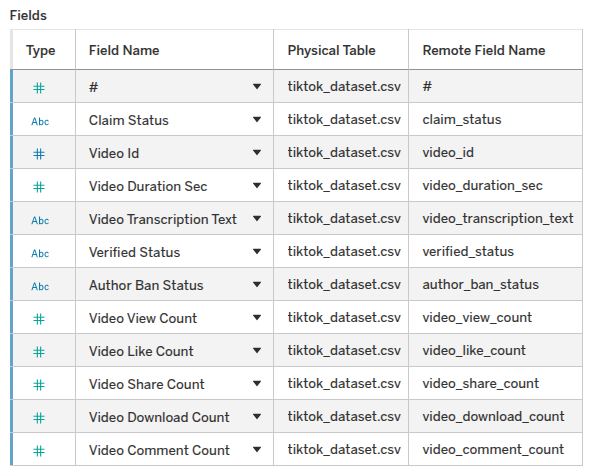


### **Part 2c. Selecting visualization types**

Selecting data visualization types that will help us understand and explain the data.

Now that we know which data columns we'll use, it is time to decide which data visualization makes the most sense for EDA of the TikTok dataset. The type of data visualizations that would be most helpful considering the distribution of the data:

* Bar chart
* Box plot
* Histogram
* Scatter plot

Box plots and histograms would be my first choices to explore the data and scatterplot is very useful for discovering relations between variables. On the other hand bar plots are useful for comparison.

## **PACE: Construct**

### **Part 3. Building visualizations**

Now that we have assessed our data, it's time to plot visualizations.

#### **video_duration_sec**

We'll create a box plot to examine the spread of values in the `video_duration_sec` column.

<Axes: xlabel='video_duration_sec'>

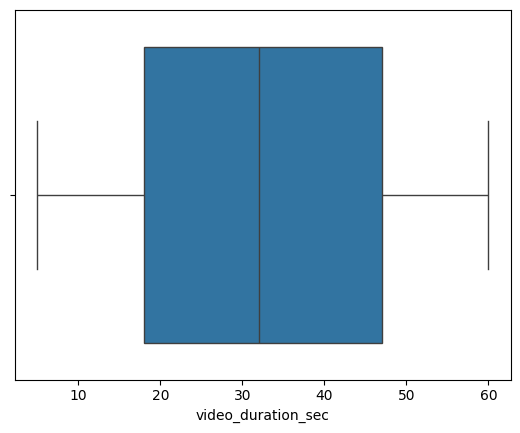

In [12]:
# Creating a boxplot to visualize distribution of `video_duration_sec`
sns.boxplot(x=data['video_duration_sec'])


we'll create a histogram of the values in the `video_duration_sec` column to further explore the distribution of this variable.

<Axes: xlabel='video_duration_sec', ylabel='Count'>

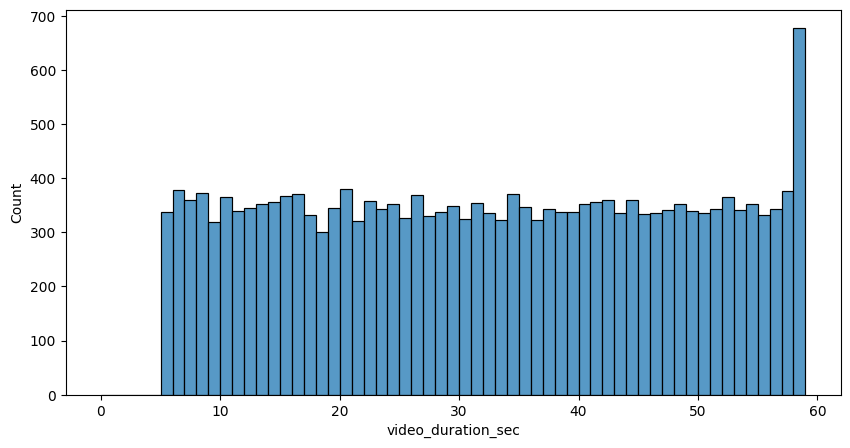

In [13]:
# Creating a histogram
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='video_duration_sec',bins=range(0,60,1))


The distribution is approximately uniform, but the highest percentage are about 59 sec. And there are no outliers.

#### **video_view_count**

We'll create a box plot to examine the spread of values in the `video_view_count` column.

<Axes: xlabel='video_view_count'>

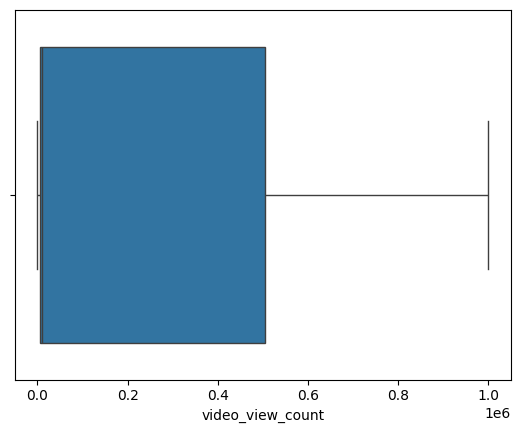

In [14]:
# Creating a boxplot to visualize distribution of `video_view_count`
sns.boxplot(x=data['video_view_count'])


We'll create a histogram of the values in the `video_view_count` column to further explore the distribution of this variable.

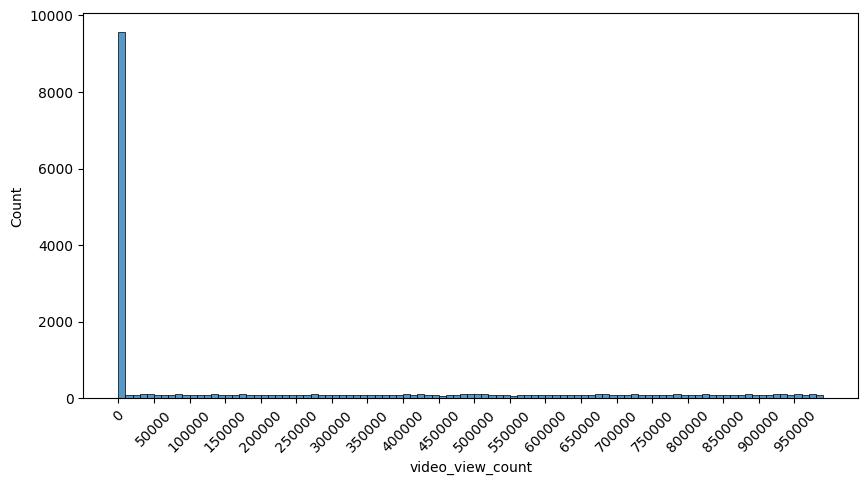

In [15]:
# Creating a histogram
plt.figure(figsize=(10,5))
g = sns.histplot(data=data,x='video_view_count', bins=range(0,int(1e6),10000))
g.set_xticks(range(0,int(1e6),50000));
g.set_xticklabels(range(0,int(1e6),50000), rotation = 45);

Most of the values are about 10000, but there is outliers that skew the distribution to the right.

#### **video_like_count**

We'll create a box plot to examine the spread of values in the `video_like_count` column.

<Axes: xlabel='video_like_count'>

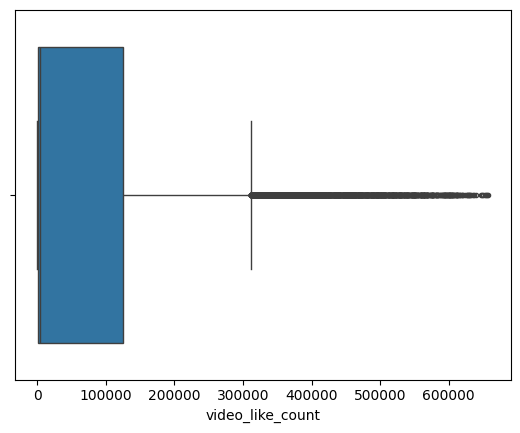

In [16]:
# Creating a boxplot to visualize distribution of `video_like_count`
sns.boxplot(x=data['video_like_count'],fliersize=3)



We'll create a histogram of the values in the `video_like_count` column to further explore the distribution of this variable.

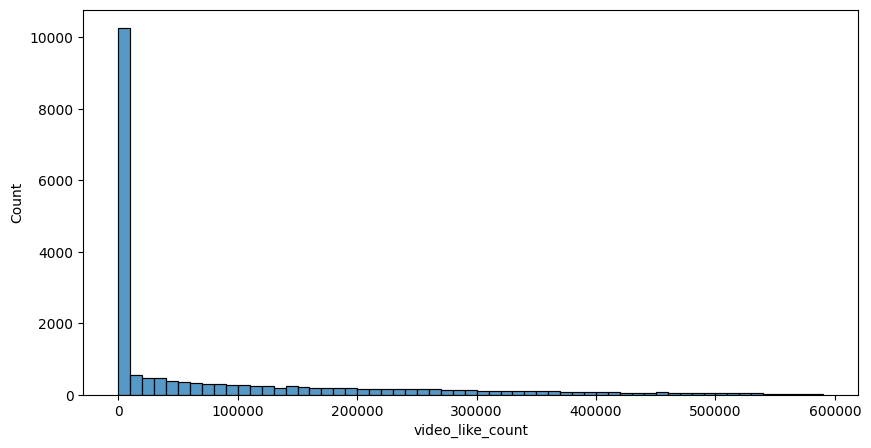

In [17]:
# Creating a histogram
plt.figure(figsize=(10,5))
g = sns.histplot(data=data,x='video_like_count', bins=range(0,600000,10000))

This variable contains many outlier that skew the distribution (righ-skewed) while most video had about 10000 like.

#### **video_comment_count**

We'll create a box plot to examine the spread of values in the `video_comment_count` column.

<Axes: xlabel='video_comment_count'>

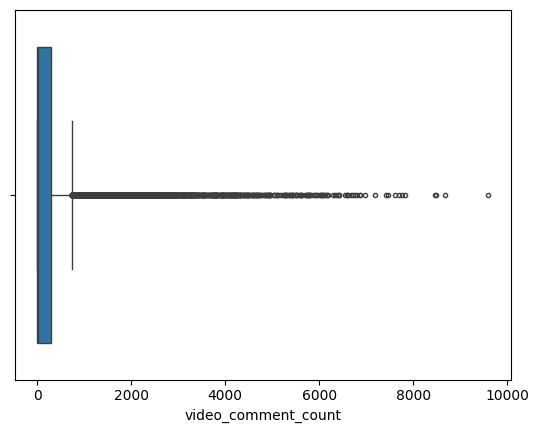

In [18]:
# Creating a boxplot to visualize distribution of `video_comment_count`
sns.boxplot(x=data['video_comment_count'],fliersize=3)



We'll create a histogram of the values in the `video_comment_count` column to further explore the distribution of this variable.

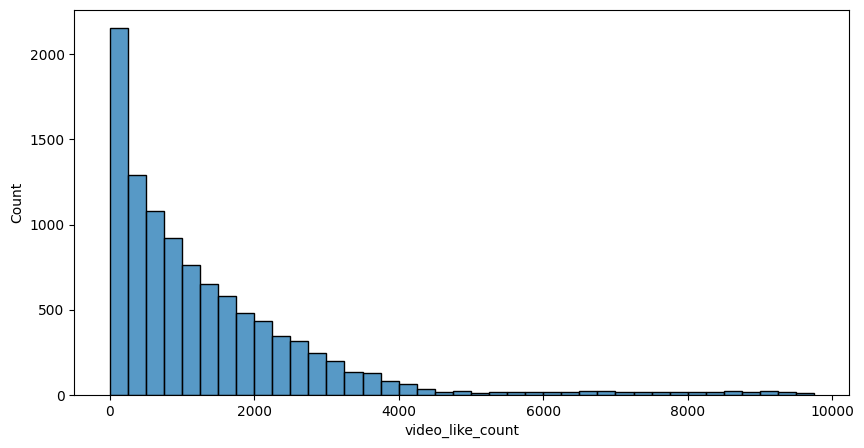

In [19]:
# Creating a histogram
plt.figure(figsize=(10,5))
g = sns.histplot(data=data,x='video_like_count', bins=range(0,10000,250))


This variable contains many outlier that skew the distribution (righ-skewed) while most video had less than 2000 comment.

#### **video_share_count**

We'll create a box plot to examine the spread of values in the `video_share_count` column.

<Axes: xlabel='video_share_count'>

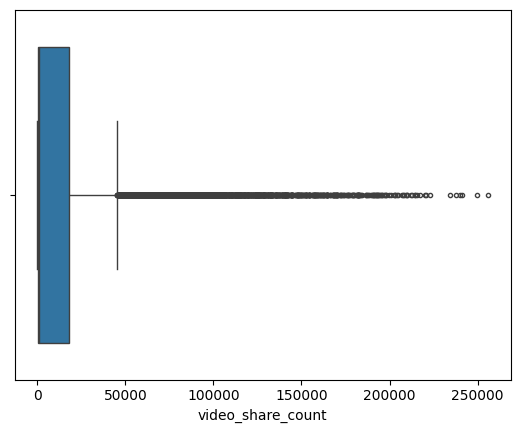

In [20]:
# Creating a boxplot to visualize distribution of `video_share_count`
sns.boxplot(x=data['video_share_count'],fliersize=3)


*We'll create* a histogram of the values in the `video_share_count` column to further explore the distribution of this variable.

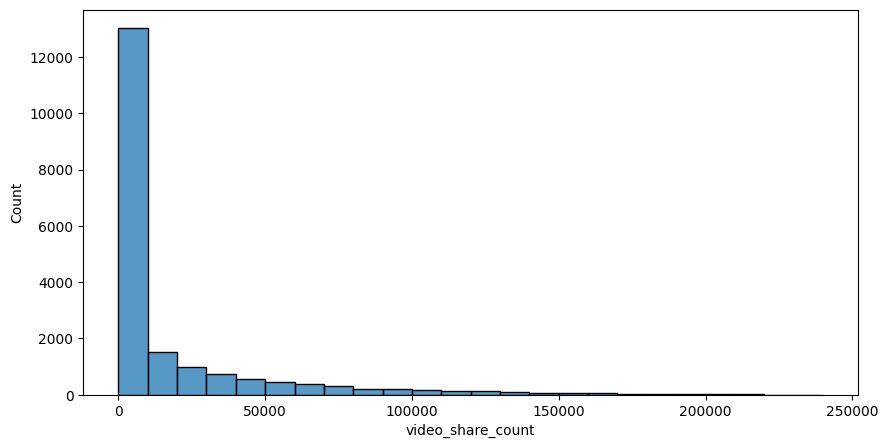

In [21]:
# Creating a histogram
plt.figure(figsize=(10,5))
g = sns.histplot(data=data,x='video_share_count', bins=range(0,250000,10000))


This variable contains many outlier that skew the distribution (righ-skewed) while most video had less than 10000 share.

#### **video_download_count**

We'll create a box plot to examine the spread of values in the `video_download_count` column.

<Axes: xlabel='video_download_count'>

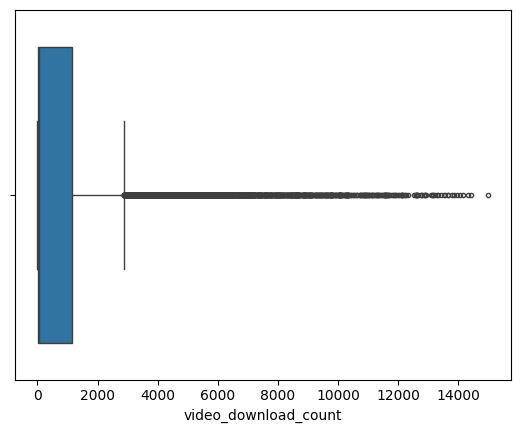

In [22]:
# Creating a boxplot to visualize distribution of `video_download_count`
sns.boxplot(x=data['video_download_count'],fliersize=3)


We'll create a histogram of the values in the `video_download_count` column to further explore the distribution of this variable.

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


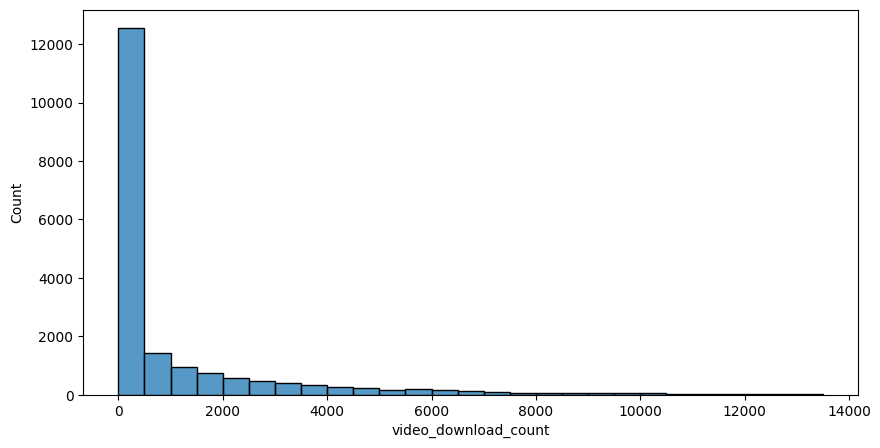

In [23]:
# Creating a histogram
plt.figure(figsize=(10,5))
g = sns.histplot(data=data,x='video_download_count', bins=range(0,14000,500))
data.head()

This variable contains many outlier that skew the distribution (righ-skewed) while most video had less than 500 download.

#### **Claim status by verification status**

Now, we'll create a histogram with four bars: one for each combination of claim status and verification status.

<Axes: xlabel='claim_status', ylabel='Count'>

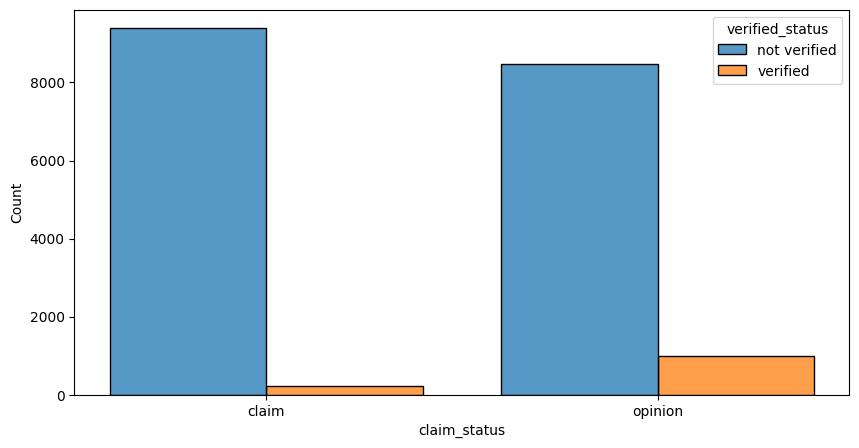

In [24]:
# Creating a histogram
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='claim_status', hue='verified_status', multiple='dodge', shrink=0.8)

Unverified users are much more than verified. Its most likely that a verified user post an opinion and vice-versa.

#### **Claim status by author ban status**

The previous stage used a `groupby()` statement to examine the count of each claim status for each author ban status. Now, we'll use a histogram to communicate the same information.

<Axes: xlabel='claim_status', ylabel='Count'>

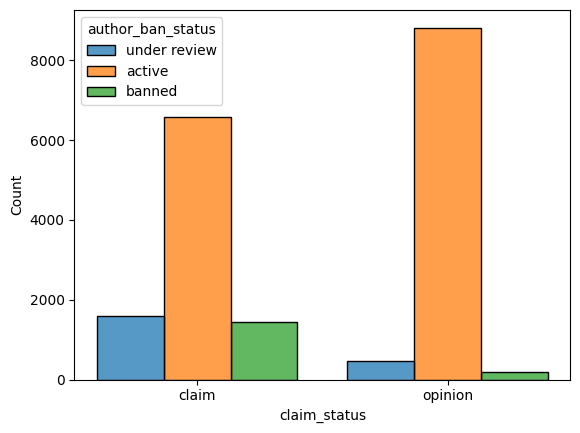

In [25]:
# Creating a histogram
sns.histplot(data=data, x='claim_status', hue='author_ban_status', multiple='dodge', shrink=0.8)

Active users represent the highest percentage for both cases . Banned and Under review users tend to post more claims and vice-versa for active users.

#### **Median view counts by ban status**

We'll create a bar plot with three bars: one for each author ban status. The height of each bar should correspond with the median number of views for all videos with that author ban status.

<Axes: xlabel='author_ban_status', ylabel='video_view_count'>

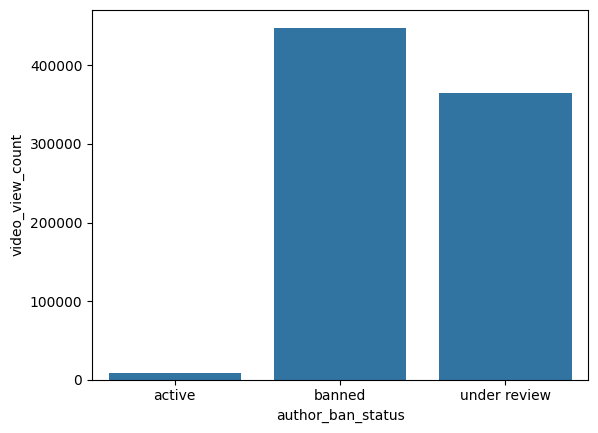

In [26]:
# Creating a bar plot
myplot = data.groupby('author_ban_status')['video_view_count'].median()
sns.barplot(x=myplot.index, y=myplot)


Non-active authors tend to get much more views on their videos, therefore ban status can be a good indicator of claim status. This will be checked in next cells.

<Axes: xlabel='claim_status', ylabel='video_view_count'>

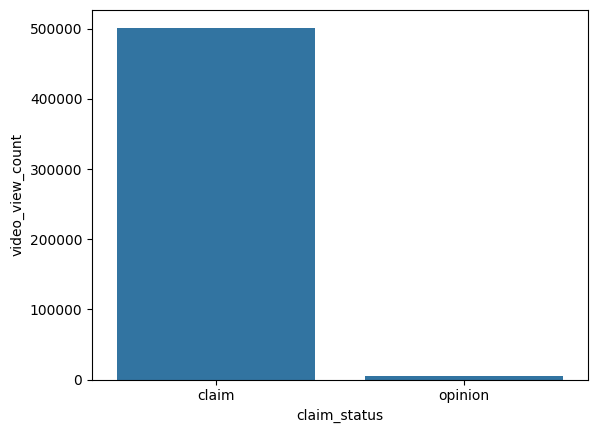

In [27]:
# Calculate the median view count for claim status.
myplot = data.groupby('claim_status')['video_view_count'].median()
sns.barplot(x=myplot.index, y=myplot)

#### **Total views by claim status**

We'll create a pie graph that depicts the proportions of total views for claim videos and total views for opinion videos.

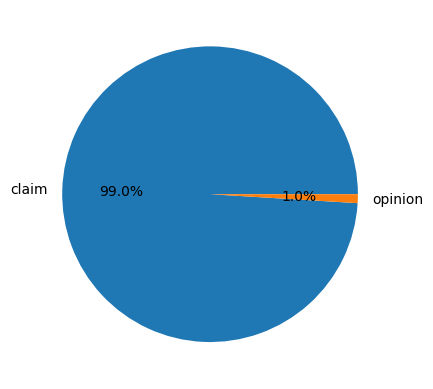

In [28]:
# Creating a pie graph
myplot = data.groupby('claim_status')['video_view_count'].sum()
plt.pie(myplot, labels=['claim','opinion'], autopct='%1.1f%%');

99% of total views go to claim status

### **Part 4. Determining outliers**

When building predictive models, the presence of outliers can be problematic. For example, if we were trying to predict the view count of a particular video, videos with extremely high view counts might introduce bias to a model. Also, some outliers might indicate problems with how data was captured or recorded.

The ultimate objective of the TikTok project is to build a model that predicts whether a video is a claim or opinion. The analysis we've performed indicates that a video's engagement level is strongly correlated with its claim status. There's no reason to believe that any of the values in the TikTok data are erroneously captured, and they align with expectation of how social media works: a very small proportion of videos get super high engagement levels. That's the nature of viral content.

Nonetheless, it's good practice to get a sense of just how many of our data points could be considered outliers. The definition of an outlier can change based on the details of our project, and it helps to have domain expertise to decide a threshold. I've learned that a common way to determine outliers in a normal distribution is to calculate the interquartile range (IQR) and set a threshold that is 1.5 * IQR above the 3rd quartile.

In this TikTok dataset, the values for the count variables are not normally distributed. They are heavily skewed to the right. One way of modifying the outlier threshold is by calculating the **median** value for each variable and then adding 1.5 * IQR. This results in a threshold that is, in this case, much lower than it would be if I used the 3rd quartile.

we'll rite a for loop that iterates over the column names of each count variable. For each iteration, we will:
1. Calculate the IQR of the column
2. Calculate the median of the column
3. Calculate the outlier threshold (median + 1.5 * IQR)
4. Calculate the numer of videos with a count in that column that exceeds the outlier threshold
5. Print "Number of outliers, {column name}: {outlier count}"


In [29]:
iqr = []
medians=[]
thresholds = []
counts = []
for i,column in enumerate(data[['video_view_count','video_like_count','video_share_count','video_download_count','video_comment_count']].columns):
    iqr.append(data[column].quantile(0.75) - data[column].quantile(0.25))
    medians.append(data[column].median())
    thresholds.append(medians[i] + 1.5*iqr[i])
    counts.append(data[data[column] > thresholds[i]].shape[0])
    print(f"Number of outliers, {column}: {counts[i]}")


Number of outliers, video_view_count: 2343
Number of outliers, video_like_count: 3468
Number of outliers, video_share_count: 3732
Number of outliers, video_download_count: 3733
Number of outliers, video_comment_count: 3882


#### **Scatterplot**

<Axes: xlabel='video_like_count', ylabel='video_view_count'>

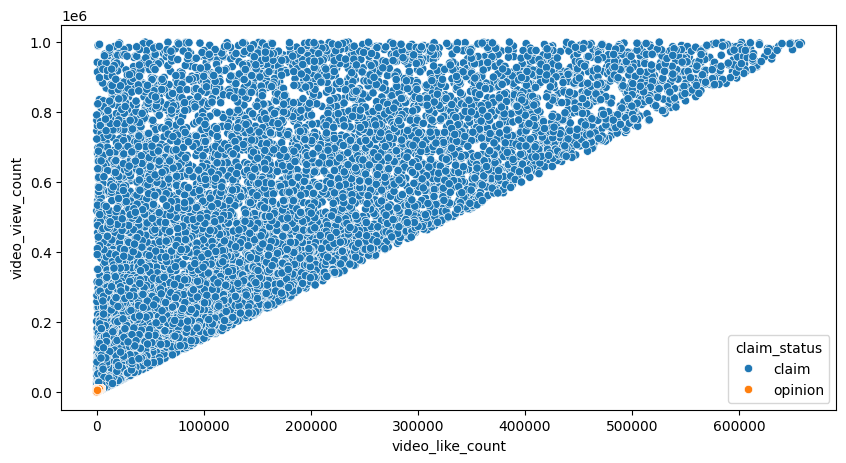

In [30]:
# Creating a scatterplot of `video_view_count` versus `video_like_count` according to 'claim_status'
plt.figure(figsize=(10,5))
sns.scatterplot(data=data,x='video_like_count',y='video_view_count', hue='claim_status')

<Axes: xlabel='video_like_count', ylabel='video_view_count'>

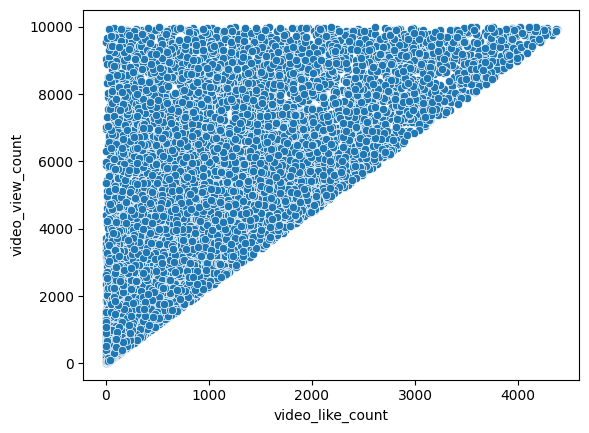

In [31]:
# Creating a scatterplot of ``video_view_count` versus `video_like_count` for opinions only
sns.scatterplot(data=data[data['claim_status']=='opinion'],x='video_like_count',y='video_view_count')


I did a scatterplot in Tableau Public as well, which can be easier to manipulate and present.

## **PACE: Execute**


### **Part 5a. Results and evaluation**

Having built visualizations in Tableau and in Python, here's the summary:

+ The vizz need more labeling and titling before putting into use and sent to stakeholders so that they become easier to understand.

+ We have learned: Videos that are classified as claims and/or banned author are getting much more reaction and interactions that others. Also 99% of this data are classifid as claim which might cause a bias in the data. Furthermore, the column that record views, likes, comments, shares and downloads contain high amount of outliers, which skewed their distributions to the right.

+ My other questions are: Why this data set contains 99% of its classification as claims? Does it fairly represent the population?

+ My client would likely want to know: video duration is not an important factor and its uniformly distributed. Count columns contain outliers and etc of insights menthion in `We have learned` section above.



### **Part 5b. Conclusion**
We have visualized the data we need to share with the director now. The goal of a data visualization was for an audience member to glean the information on the chart in mere seconds.


+ EDA is important because it reveals a lot of details behined the data, and it includes cleaning, structring and validating the dataset and making sure it's in its appropriate format for further analysis and modeling.

+ Visualizations helped me in identifing outliers, distrbution of the data and the percentage of values in the data in addition to the correlation between them.
